In [ ]:
dir(models)

In [2]:
import torch
import fastai
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from fastai.vision.all import *
from fastai.vision.augment import *
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [ ]:

fields = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
)

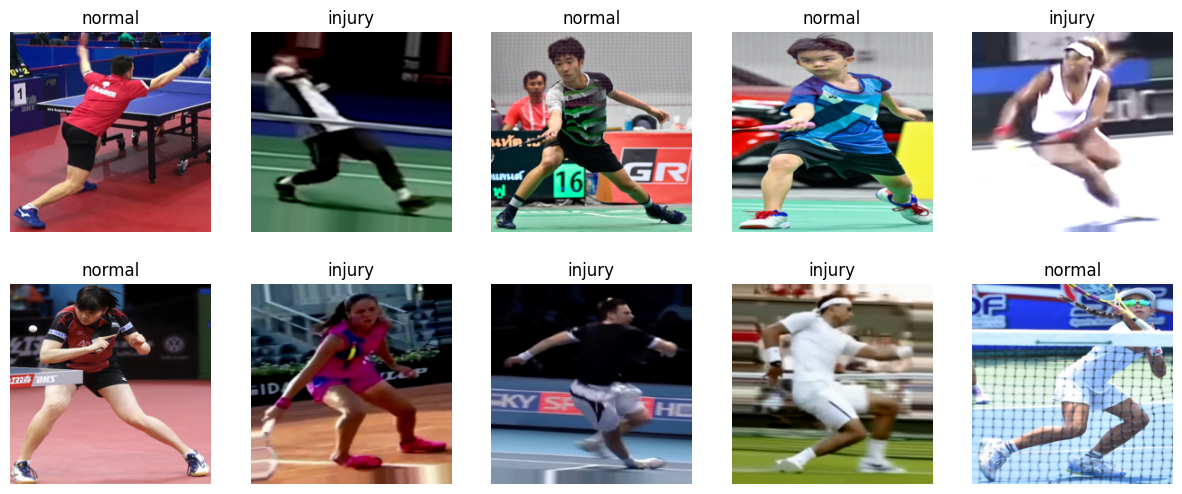

In [ ]:
fields = fields.new(item_tfms=Resize(224, method=ResizeMethod.Squish))
# dls = fields.dataloaders("/content/gdrive/MyDrive/data3/tr")
dls = fields.dataloaders("/content/drive/MyDrive/trainv3/")
dls.train.show_batch(max_n=10,nrows=2)

In [ ]:
fields = fields.new(item_tfms=Resize(200, method=ResizeMethod.Squish),batch_tfms=aug_transforms(p_lighting=1.0,p_affine=1.0,max_warp=0,max_lighting=0.4,min_zoom=1,max_zoom=1,max_rotate=10.0))
dls = fields.dataloaders("/content/gdrive/MyDrive/data/tr")
dls.train.show_batch(max_n=10,nrows=2,unique=True)

In [ ]:
# dls = fields.dataloaders("/content/gdrive/MyDrive/Colab Notebooks/data/tr/")
# dls = fields.dataloaders("/content/gdrive/MyDrive/data/tr")

In [ ]:
# get_image_files('/content/gdrive/MyDrive/Colab Notebooks/data/tr/')
get_image_files("/content/gdrive/MyDrive/data2/tr")

(#971) [Path('/content/gdrive/MyDrive/data2/tr/injury/aug_6_1180019.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_35_8934211.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_45_204059.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_38_3064121.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_9_8461194.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_4_8944949.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_78_4507960.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_12_8278741.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_72_3611470.png'),Path('/content/gdrive/MyDrive/data2/tr/injury/aug_18_9908892.png')...]

In [ ]:
dls.vocab

['injury', 'normal']

In [ ]:
dls.train.show_batch(max_n=100, nrows=9)

In [ ]:
dls.valid.show_batch(max_n=100, nrows=9)

In [ ]:
learner = vision_learner(dls, swin_v2_t, metrics=[error_rate, accuracy,Precision(),Recall(),F1Score(),RocAucBinary()])

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Swin_V2_T_Weights.IMAGENET1K_V1`. You can also use `weights=Swin_V2_T_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/swin_v2_t-b137f0e2.pth" to /root/.cache/torch/hub/checkpoints/swin_v2_t-b137f0e2.pth
100%|██████████| 109M/109M [00:33<00:00, 3.41MB/s]


In [ ]:
learner.summary()

Sequential (Input shape: 64 x 3 x 224 x 224)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 96 x 56 x 56   
Conv2d                                    4704       False     
____________________________________________________________________________
                     64 x 56 x 56 x 96   
Permute                                                        
LayerNorm                                 192        True      
LayerNorm                                 192        True      
____________________________________________________________________________
                     64 x 15 x 15 x 512  
Linear                                    1536       False     
ReLU                                                           
____________________________________________________________________________
                     64 x 15 x 15 x 3    
Linear                                    1536       False     
StochasticDepth                             

In [ ]:
import time

SuggestedLRs(valley=0.0014454397605732083)

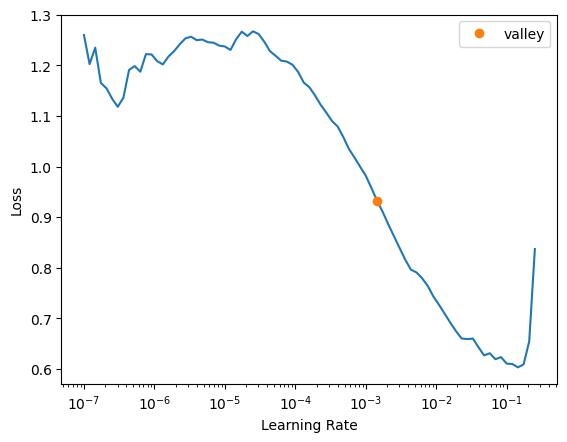

In [ ]:
learner.lr_find()

In [ ]:
t0 = time.time()
learner.fine_tune(epochs=25, base_lr=0.0004 ,freeze_epochs=0 ) #12:51 0.997494
print("Training time:", time.time()-t0)

epoch,train_loss,valid_loss,error_rate,accuracy,precision_score,recall_score,f1_score,roc_auc_score,time
0,0.871567,0.385348,0.158311,0.841689,0.813131,0.875000,0.842932,0.915162,05:29
1,0.666912,0.226864,0.081794,0.918206,0.873171,0.972826,0.920308,0.976059,01:00
2,0.528678,0.140046,0.047493,0.952507,0.927835,0.978261,0.952381,0.991499,00:58
3,0.417830,0.088650,0.036939,0.963061,0.942708,0.983696,0.962766,0.997129,01:03
4,0.328469,0.066090,0.029024,0.970976,0.948187,0.994565,0.970822,0.998606,00:59
5,0.255627,0.047757,0.021108,0.978892,0.963158,0.994565,0.978610,0.999526,00:59
6,0.203012,0.033211,0.015831,0.984169,0.973404,0.994565,0.983871,0.999777,01:03
7,0.160935,0.038961,0.015831,0.984169,0.973404,0.994565,0.983871,0.999721,00:58
8,0.130012,0.023695,0.007916,0.992084,0.983957,1.000000,0.991914,0.999972,00:59
9,0.110472,0.015303,0.007916,0.992084,0.983957,1.000000,0.991914,1.000000,00:59


Training time: 1775.047512292862


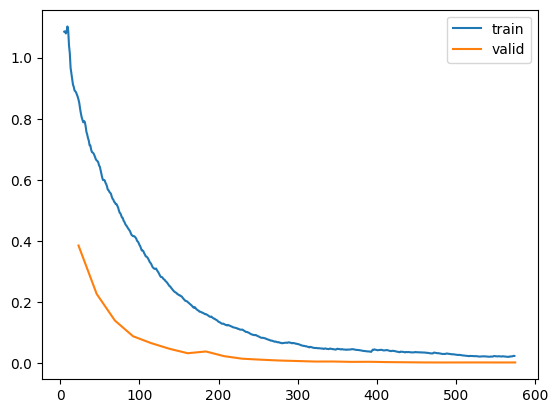

In [ ]:
learner.recorder.plot_loss()

In [ ]:
@patch
@delegates(subplots)
def plot_metrics(self: Recorder, nrows=None, ncols=None, figsize=None, **kwargs):
    metrics = np.stack(self.values)
    names = self.metric_names[1:-1]
    n = len(names) - 1
    if nrows is None and ncols is None:
        nrows = int(math.sqrt(n))
        ncols = int(np.ceil(n / nrows))
    elif nrows is None: nrows = int(np.ceil(n / ncols))
    elif ncols is None: ncols = int(np.ceil(n / nrows))
    figsize = figsize or (ncols * 6, nrows * 4)
    fig, axs = subplots(nrows, ncols, figsize=figsize, **kwargs)
    axs = [ax if i < n else ax.set_axis_off() for i, ax in enumerate(axs.flatten())][:n]
    for i, (name, ax) in enumerate(zip(names, [axs[0]] + axs)):
        ax.plot(metrics[:, i], color='#1f77b4' if i == 0 else '#ff7f0e', label='valid' if i > 0 else 'train')
        ax.set_title(name if i > 1 else 'losses')
        ax.legend(loc='best')
    plt.show()

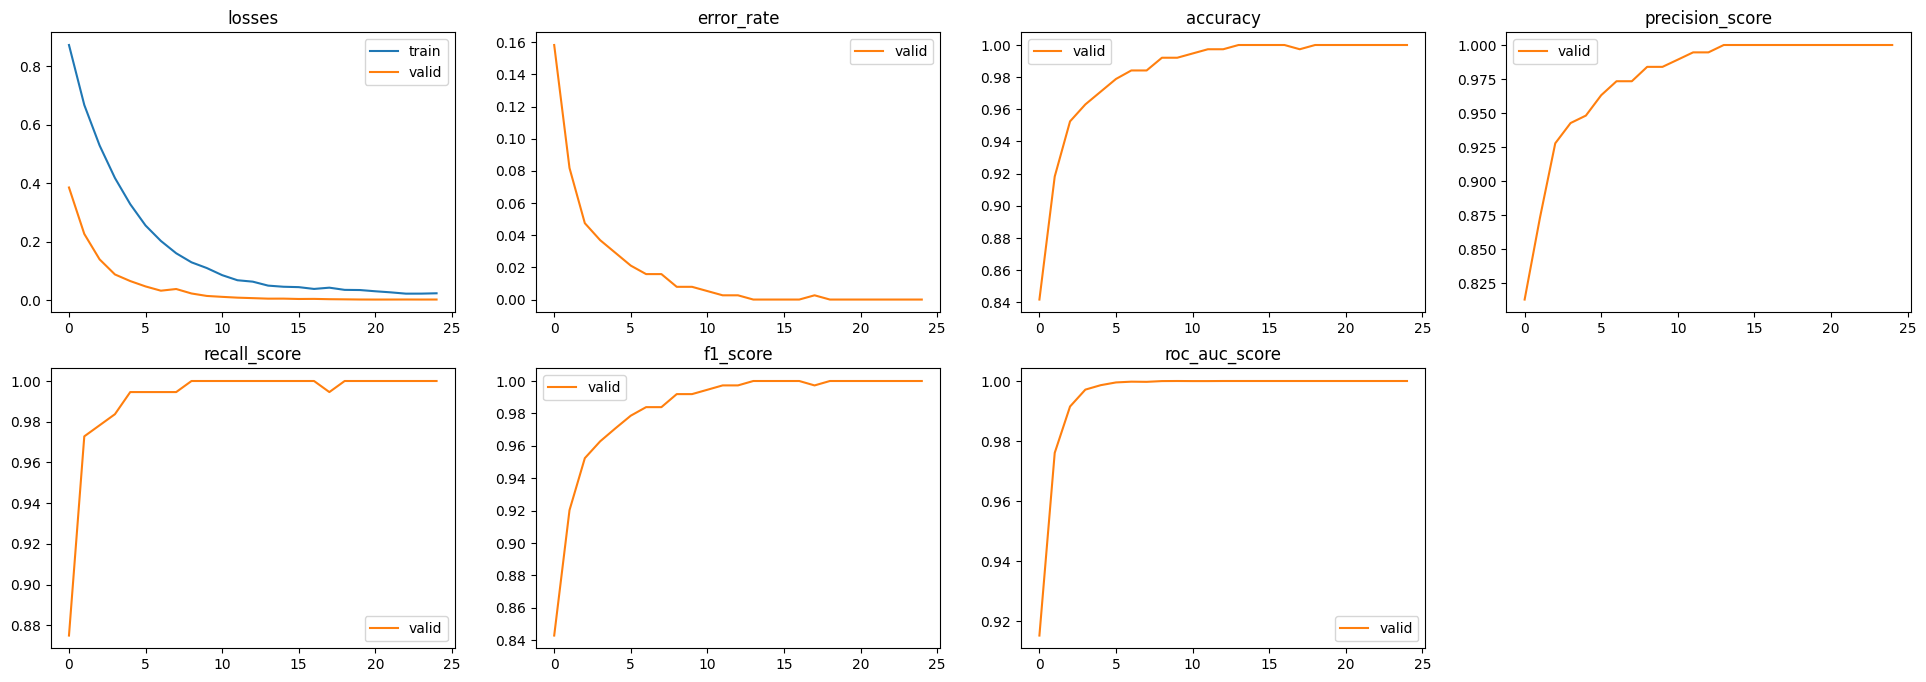

In [ ]:
learner.recorder.plot_metrics()

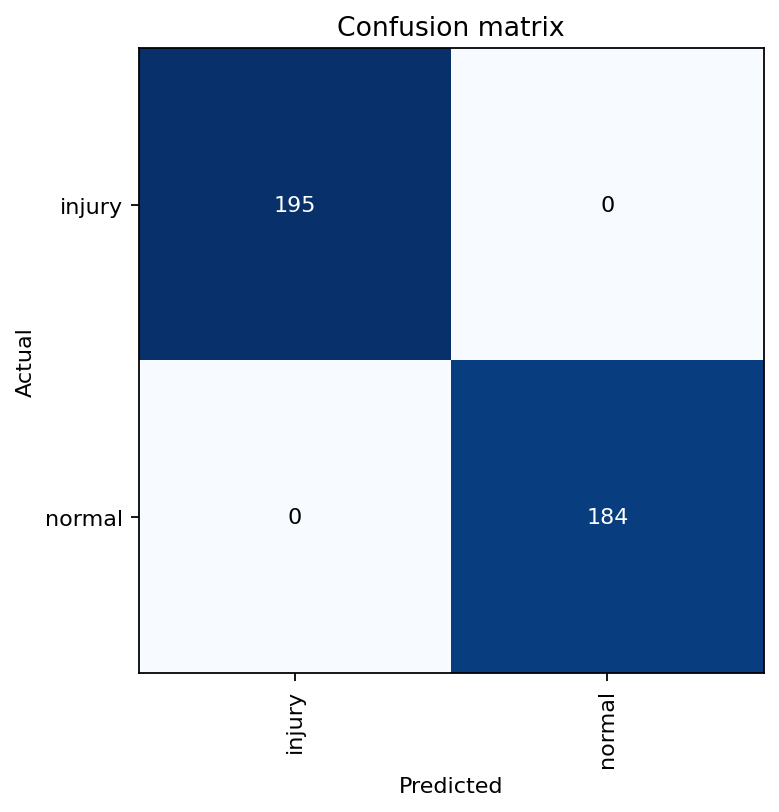

In [ ]:
interp = ClassificationInterpretation.from_learner(learner)
interp.plot_confusion_matrix(figsize=(5,5), dpi=160)

In [ ]:
interp.plot_top_losses(2, figsize=(5,5))

ValueError: ignored

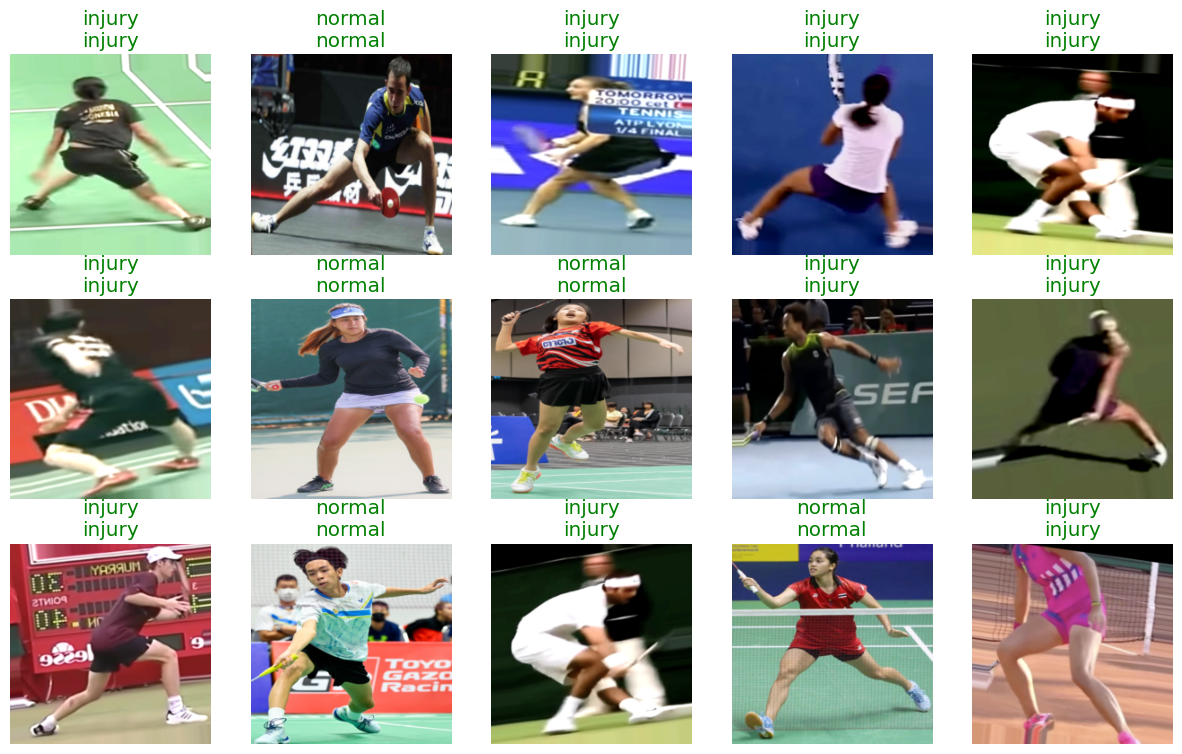

In [ ]:
learner.show_results(max_n=15,shuffle=True)

In [ ]:
learner.evaluluate()

AttributeError: ignored

Yahoo

In [ ]:
learner.export("resnet50_fastai_binary.pkl")

In [3]:
from fastbook import *
from glob import glob
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_auc_score

learn_inf = load_learner('/content/8_xresnet50_fastai_binary.pkl')

ModuleNotFoundError: ignored

In [ ]:
tt=Image.open("/content/gdrive/MyDrive/Colab Notebooks/data/te/yahoo/n322.jpg").resize((224, 224))

In [ ]:
p=learn_inf.predict(tt)

In [7]:
import time
from glob import glob
from pathlib import Path

In [5]:
pp =load_learner('/content/drive/MyDrive/pklmodel/swinv2_t.pkl')

Testing time: 58.51573419570923
Time per image: -0.36394646115925 seconds


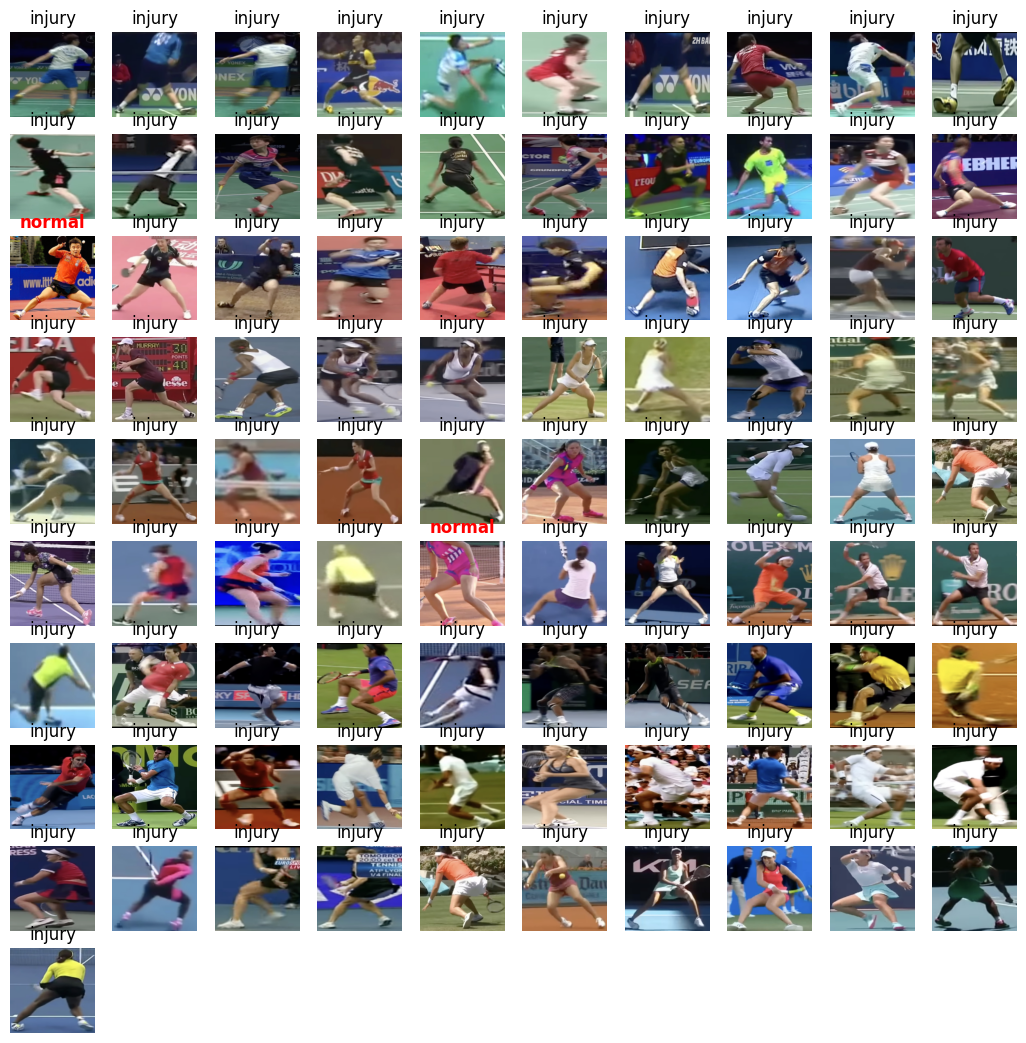

In [9]:
t2 = time.time()
plt.figure(figsize=(13,13))
jj=('/content/drive/MyDrive/data3/te/injury/')
# jj=('/content/gdrive/MyDrive/Colab Notebooks/data2/te/yahoo/')
# p = os.listdir('data/')
c=1
for i in os.listdir(jj)[:91]:
    plt.subplot(10,10,c)
    img = Image.open(jj+i).resize((200, 200))
    # img1 = cv2.resize(img,(50,50))
    # img1 = img1.reshape(1,-1)/255
    # img1=np.array (img1).flatten()
    # img1=img1.convert("L")
    pred_class, pred_idx, outputs =pp.predict(img)
    plt.title(pred_class) if pred_class == "injury" else plt.title(pred_class ,weight='bold',color='red')
    #plt.title(outputs[1],loc='right',size='small',style='italic', weight='bold')
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1
    #print(c)
print("Testing time:", time.time()-t2)
time_per_image = (time.time()-t2)/ c-1
print("Time per image:", time_per_image, "seconds")

In [10]:
t1 = time.time()


plt.figure(figsize=(13,13))
jj=('/content/drive/MyDrive/data3/te/normal/')
# jj=('/content/gdrive/MyDrive/Colab Notebooks/data2/te/yahoo/')
# p = os.listdir('data/')
c=1
for i in os.listdir(jj)[:98]:
    plt.subplot(10,10,c)
    img = Image.open(jj+i).convert('RGB').resize((200, 200))
    # img1 = cv2.resize(img,(50,50))
    # img1 = img1.reshape(1,-1)/255
    # img1=np.array (img1).flatten()
    # img1=img1.convert("L")
    pred_class, pred_idx, outputs =pp.predict(img)
    plt.title(pred_class) if pred_class == "normal" else plt.title(pred_class ,weight='bold',color='red')
    #plt.title(outputs[1],loc='right',size='small',style='italic', weight='bold')
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    c+=1
    #print(c)
print("Testing time:", time.time()-t1)
time_per_image = (time.time()-t1)/ c-1
print("Time per image:", time_per_image, "seconds")

Output hidden; open in https://colab.research.google.com to view.